In [1]:
import pandas as pd

In [2]:
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print(f"train_transaction: {train_transaction.shape}")
print(f"train_identity:    {train_identity.shape}")

train_transaction: (590540, 394)
train_identity:    (144233, 41)


In [ ]:
df = train_transaction.merge(train_identity, on='TransactionID', how='left') 

print(f"Joined dataset: {df.shape}")
print(f"Rows with identity info: {df['id_01'].notna().sum()} / {len(df)}")
df.head()

Joined dataset: (590540, 434)
Rows with identity info: 144233 / 590540


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Class Imbalance — Target Variable (`isFraud`)

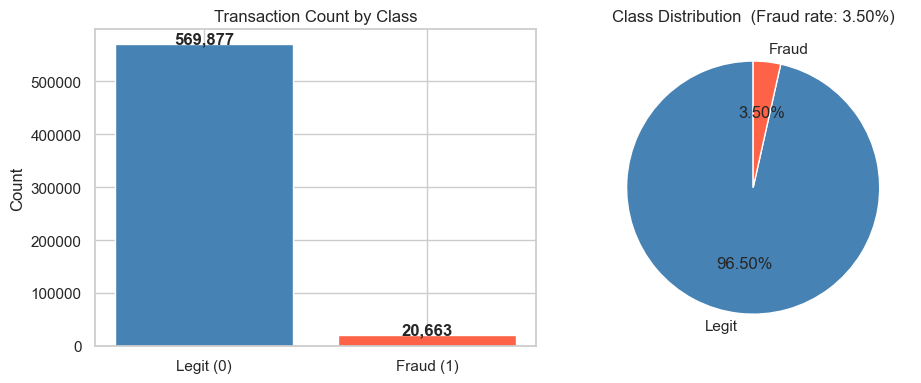

In [5]:
counts = df['isFraud'].value_counts()
fraud_rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legit', 'Fraud'], autopct='%1.2f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title(f'Class Distribution  (Fraud rate: {fraud_rate:.2f}%)')

plt.tight_layout()
plt.show()

## 2. Transaction Amount by Class

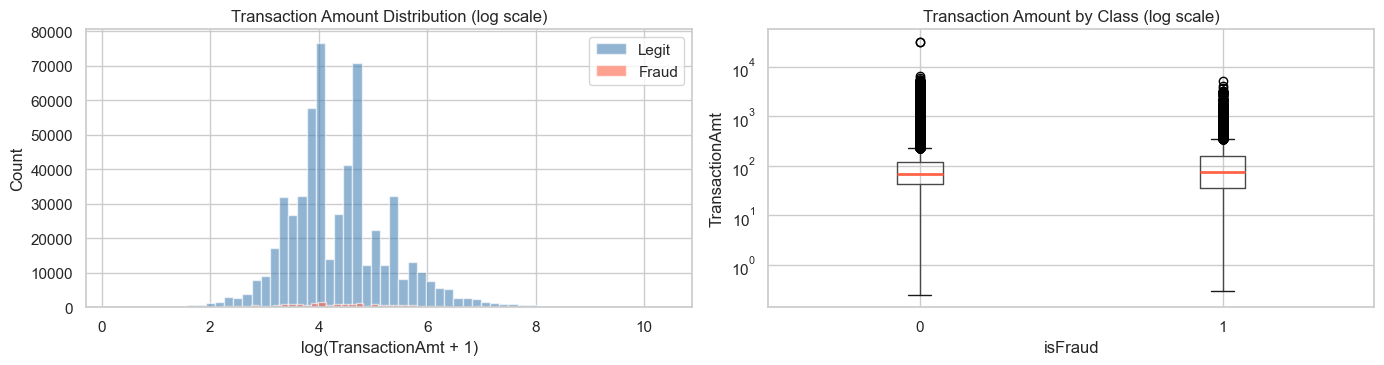

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = df[df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=60, alpha=0.6,
                 label=f"{'Fraud' if label else 'Legit'}", color=color)
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Count')
axes[0].legend()

df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1],
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount by Class (log scale)')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

## 3. Fraud Rate by Key Categorical Features

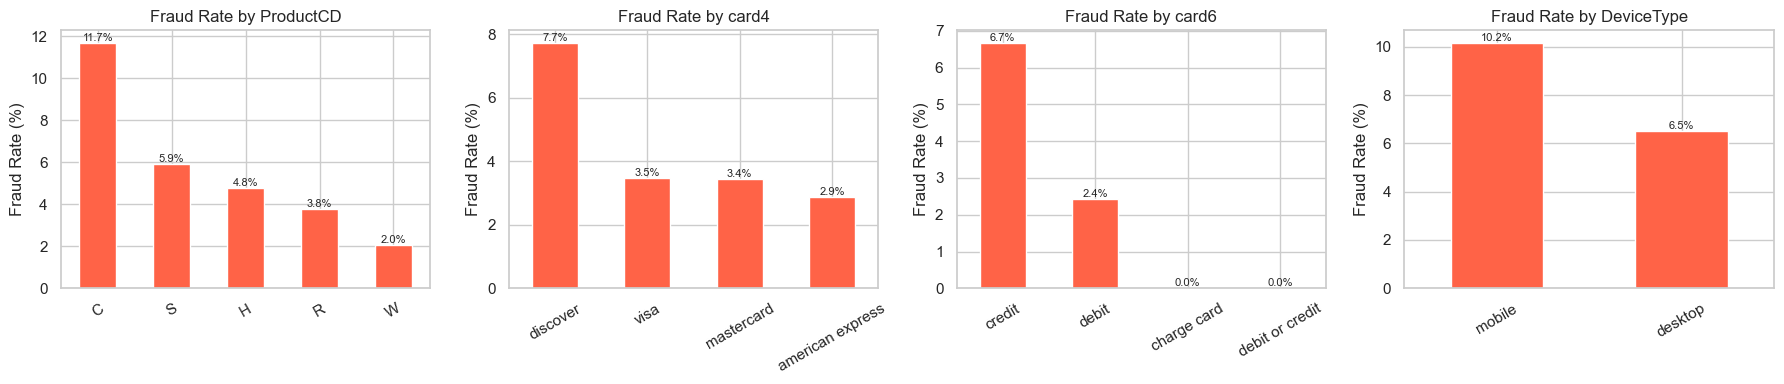

In [7]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    fraud_rate_col = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate_col.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Transaction Volume Over Time

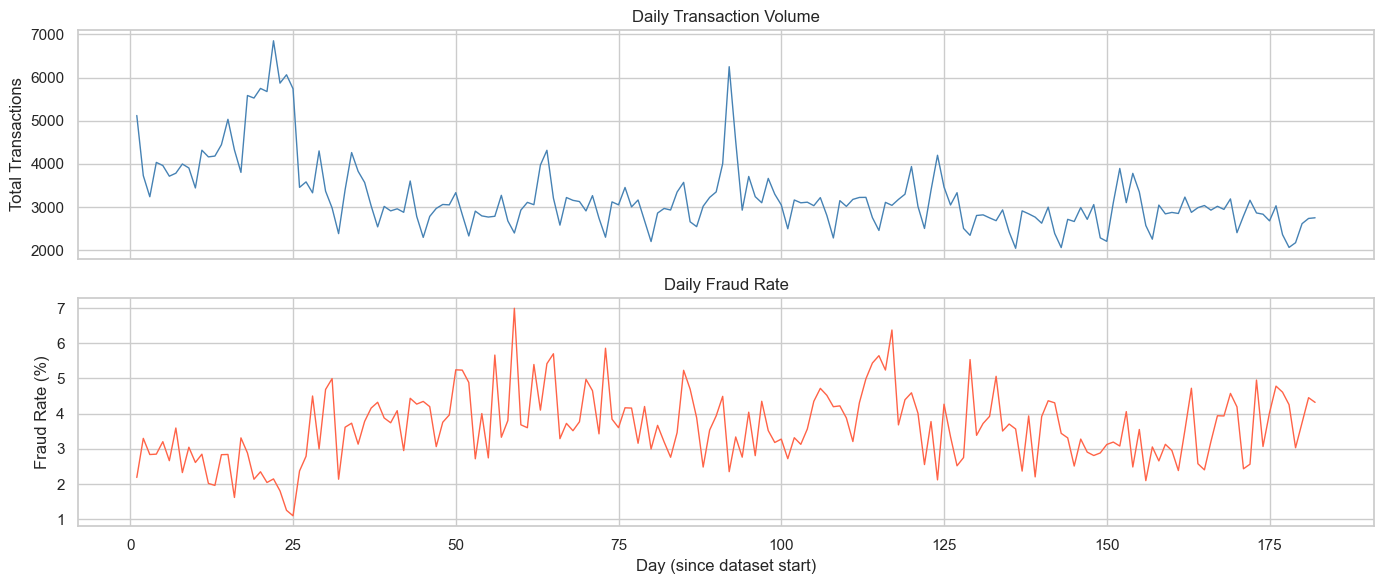

In [8]:
df['day'] = df['TransactionDT'] // 86400
daily = df.groupby('day')['isFraud'].agg(['count', 'sum'])
daily.columns = ['total', 'fraud']

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily.index, daily['total'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Total Transactions')
axes[0].set_title('Daily Transaction Volume')

axes[1].plot(daily.index, daily['fraud'] / daily['total'] * 100, color='tomato', linewidth=1)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Day (since dataset start)')
axes[1].set_title('Daily Fraud Rate')

plt.tight_layout()
plt.show()

## 5. Missing Values

Columns with missing values: 414 / 435

Missing rate buckets:
(0, 10]       92
(10, 50]     108
(50, 90]     202
(90, 100]     12
Name: count, dtype: int64


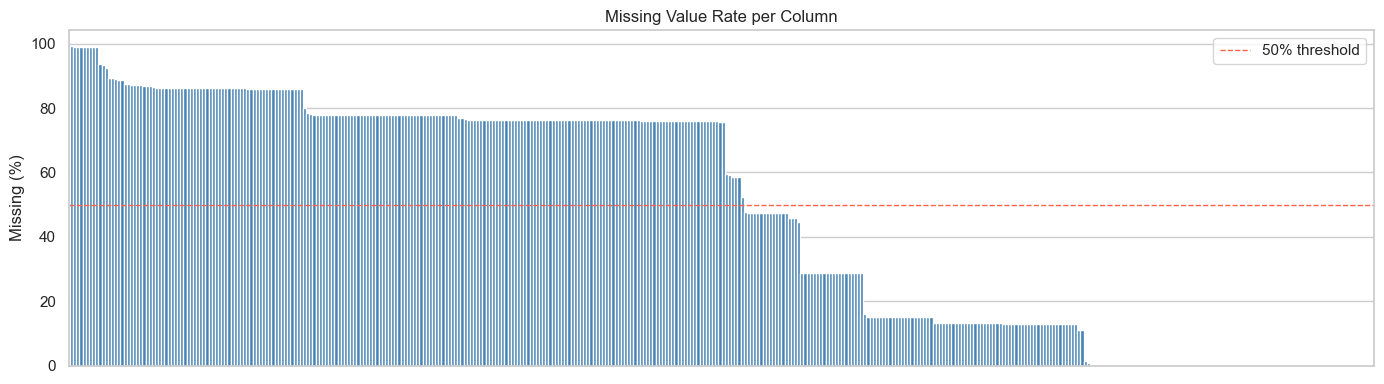

In [9]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print(f"Columns with missing values: {len(missing_nonzero)} / {df.shape[1]}")
print(f"\nMissing rate buckets:")
print(pd.cut(missing_nonzero, bins=[0, 10, 50, 90, 100]).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(14, 4))
missing_nonzero.plot(kind='bar', ax=ax, color='steelblue', width=1.0)
ax.axhline(50, color='tomato', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Missing Value Rate per Column')
ax.set_ylabel('Missing (%)')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

## 6. Top Numeric Features Correlated with Fraud

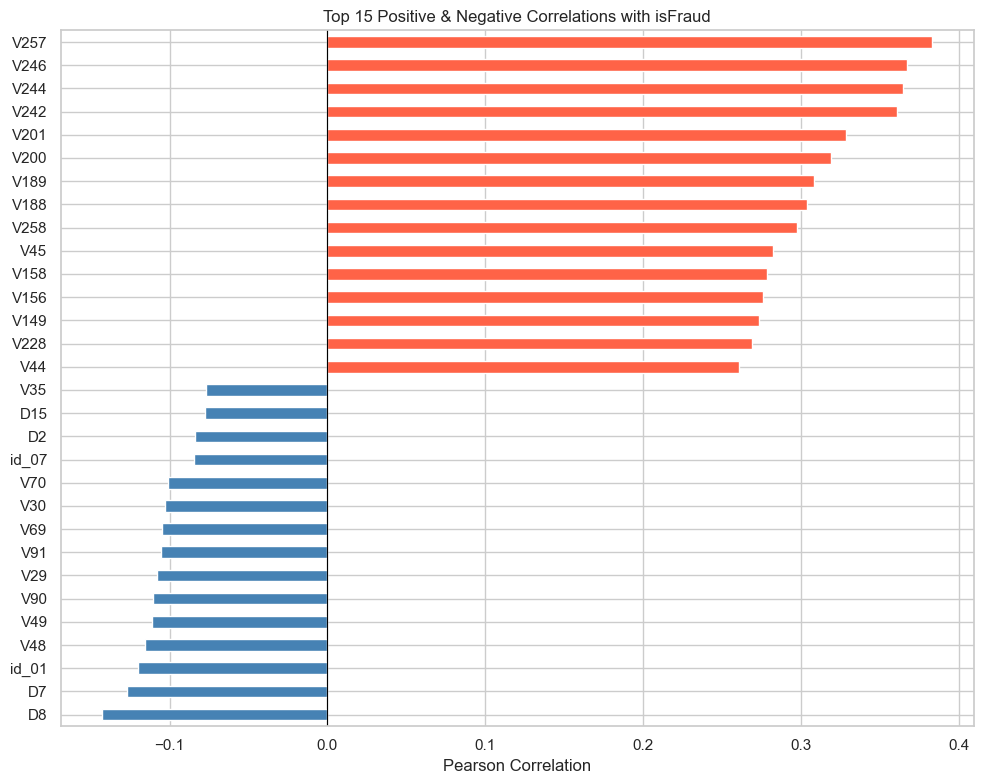

In [10]:
num_cols = df.select_dtypes(include='number').columns.drop(['TransactionID', 'TransactionDT', 'day', 'isFraud'])
corr = df[num_cols].corrwith(df['isFraud']).dropna()
top = pd.concat([corr.nlargest(15), corr.nsmallest(15)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > 0 else 'steelblue' for v in top.values]
top.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Positive & Negative Correlations with isFraud')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()